# ESC-50: does the CNN rely on digital silence?

20% of the ESC-50 clips are more than 10% *digital silence*: exact zeros used to pad short sounds to
5 s. The amount of padding depends on the class (glass breaking, sneezing and coughing are the most
padded), so it is a possible shortcut, and one that does not exist in the real world: a microphone
never outputs exact zeros, it always picks up some background noise.

**Experiment.** Take the trained `cnn_freq` models (one per fold, trained in Colab), and classify the
test clips again after adding pink noise, as a real microphone would, at 60, 40 and 20 dB SNR
(measured on the non-silent part). No retraining. **Control group**: clips without padding get exactly
the same treatment. If padded clips lose much more accuracy than the others, the network was using
the silence.

In [1]:
%load_ext autoreload
%autoreload 2

import zlib
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from audiolab.deep import predict_with_saved_folds
from audiolab.esc50 import load_clip, load_metadata
from audiolab.features import extract_logmel
from audiolab.model import AudioCNN
from audiolab.processing import add_noise

DATA = Path("../data")
ROOT = DATA / "ESC-50"
meta = load_metadata(ROOT)
y = meta.target.to_numpy()
folds = meta.fold.to_numpy()
class_names = meta.drop_duplicates("target").set_index("target").category.sort_index()
MODELS = DATA / "models" / "cnn_freq"
make_model = lambda: AudioCNN(n_classes=50, n_freq=128, keep_frequency=True)

## 1. Spectrograms with background noise

Same pipeline as in training (load at 44.1 kHz, resample to 22.05 kHz, log-mel), with the noise
added before resampling. The noise is seeded per clip, so the experiment is reproducible.

In [2]:
SNRS = [60, 40, 20]

def noisy_logmels(snr_db):
    cache = DATA / "cache" / f"esc50_logmel128_22k_pink{snr_db}.npy"
    if cache.exists():
        return np.load(cache)
    S = []
    for fn in meta.filename:
        x, fs = load_clip(ROOT, fn)                                   # original 44.1 kHz
        x = add_noise(x, snr_db, rng=zlib.crc32(f"{fn}{snr_db}".encode()))
        S.append(extract_logmel(librosa.resample(x, orig_sr=fs, target_sr=22050), 22050))
    S = np.array(S)
    np.save(cache, S)
    return S

zero_frac = np.array([np.mean(load_clip(ROOT, fn)[0] == 0) for fn in meta.filename])
padded = zero_frac > 0.1
print(f"Padded clips (>10% digital silence): {padded.sum()} | not padded: {(~padded).sum()}")

spectrograms = {"clean": np.load(DATA / "cache" / "esc50_logmel128_22k.npy")}
for snr in SNRS:
    spectrograms[f"{snr} dB"] = noisy_logmels(snr)

Padded clips (>10% digital silence): 404 | not padded: 1596


## 2. Accuracy with and without padding

In [3]:
preds = {name: predict_with_saved_folds(MODELS, make_model, S, folds) for name, S in spectrograms.items()}

gpu = np.load(DATA / "results" / "cnn_freq_gpu.npz")["pred"]
assert np.array_equal(preds["clean"], gpu), "the saved models must reproduce the training predictions"

rows = []
for name, p in preds.items():
    ok = p == y
    rows.append({"condition": name, "all clips": ok.mean(),
                 "padded clips": ok[padded].mean(), "not padded (control)": ok[~padded].mean()})
table = pd.DataFrame(rows).set_index("condition")
table.style.format("{:.1%}")

,all clips,padded clips,not padded (control)
condition,,,
clean,77.0%,76.0%,77.3%
60 dB,75.3%,67.3%,77.3%
40 dB,73.0%,59.7%,76.4%
20 dB,61.3%,33.9%,68.2%


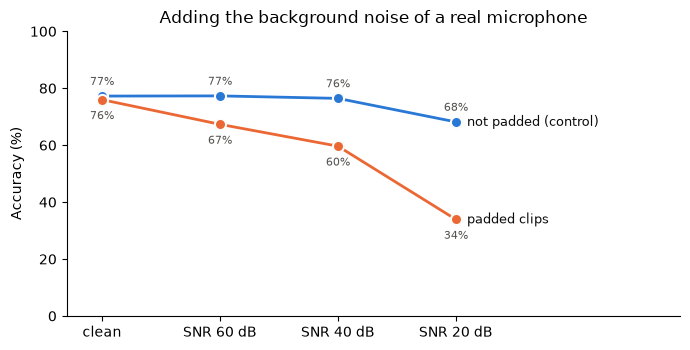

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(len(table))
for col, color in [("not padded (control)", "#2a78d6"), ("padded clips", "#eb6834")]:
    ax.plot(x, table[col] * 100, color=color, linewidth=2, marker="o", markersize=8,
            markeredgecolor="#fcfcfb", markeredgewidth=1.5)
    ax.annotate(f"{col}", (x[-1], table[col].iloc[-1] * 100), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9, color="#0b0b0b")
for i, (a, b) in enumerate(zip(table["not padded (control)"], table["padded clips"])):
    ax.annotate(f"{a:.0%}", (i, a * 100), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8, color="#52514e")
    ax.annotate(f"{b:.0%}", (i, b * 100), xytext=(0, -14), textcoords="offset points", ha="center", fontsize=8, color="#52514e")
ax.set_xticks(x, ["clean", "SNR 60 dB", "SNR 40 dB", "SNR 20 dB"])
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.set_xlim(-0.3, len(table) + 0.9)
ax.set_title("Adding the background noise of a real microphone")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Which classes suffer?

In [5]:
per_class = pd.DataFrame({name: pd.Series(p == y).groupby(y).mean() for name, p in preds.items()})
per_class.index = class_names
per_class["padding"] = pd.Series(zero_frac).groupby(y).mean().to_numpy()
per_class["drop at 40 dB"] = per_class["clean"] - per_class["40 dB"]
(per_class.sort_values("drop at 40 dB", ascending=False).head(10)
 .style.format("{:.0%}"))

,clean,60 dB,40 dB,20 dB,padding,drop at 40 dB
category,,,,,,
glass_breaking,90%,62%,38%,35%,55%,52%
rooster,88%,80%,57%,12%,38%,30%
coughing,72%,45%,45%,18%,40%,27%
car_horn,85%,80%,70%,78%,24%,15%
breathing,88%,82%,75%,57%,18%,12%
door_wood_knock,92%,90%,80%,28%,40%,12%
fireworks,78%,78%,65%,20%,1%,12%
dog,85%,72%,72%,40%,17%,12%
helicopter,30%,30%,20%,8%,3%,10%


In [6]:
r = np.corrcoef(per_class["padding"], per_class["drop at 40 dB"])[0, 1]
print(f"Correlation between how padded a class is and how much it drops at 40 dB: r = {r:.2f}")

Correlation between how padded a class is and how much it drops at 40 dB: r = 0.67


## Conclusions

- **Yes, the CNN uses digital silence as a shortcut.** Noise 60 dB below the sound, barely audible,
  changes nothing for clips without padding (77.3% → 77.3%) but costs padded clips 9 points
  (76.0% → 67.3%). The only thing that changed for them is that the exact zeros are gone.
- **The effect grows with the noise level**: at 40 dB the control group loses 0.9 points and the
  padded clips 16; at 20 dB, 9 vs. 42 points.
- **It hits the most padded classes**: glass breaking drops from 90% to 38% at 40 dB, rooster from
  88% to 57%, coughing from 72% to 45%. Across classes, padding and accuracy drop correlate with
  r = 0.67.
- **The 77% is an optimistic number for real-world use**, mostly for short, impulsive sounds. The
  fix is to train with background noise, so that silence never looks like exact zeros (next step).